In [14]:
import pandas as pd

# Load data
data = pd.read_csv('/content/drive/MyDrive/marketing_campaign.csv')
data = data.drop(columns=["Unnamed: 0"])

# Map Education column values
education_mapping = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
data['Education'] = data['Education'].map(education_mapping)

# Map Marital_Status column values
marital_status_mapping = {
    'Single': 0,
    'Together': 1,
    'Married': 2,
    'Divorced': 3,
    'Widow': 4,
    'Alone': 5,
    'Absurd': 6,
    'YOLO': 7
}
data['Marital_Status'] = data['Marital_Status'].map(marital_status_mapping)

# Extract year from Dt_Customer column
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y').dt.year

# Save modified DataFrame to new CSV
data.to_csv('/content/drive/MyDrive/marketing_campaign_modified.csv', index=False)

In [15]:
# Load modified data
data = pd.read_csv('/content/drive/MyDrive/marketing_campaign_modified.csv')

# Check for missing data
missing_data = data.isnull().sum()
proportion_missing = missing_data / len(data)
print("Missing data ratio for each feature:")
print(proportion_missing*100)

Missing data ratio for each feature:
ID                   0.000000
Year_Birth           0.000000
Education            0.000000
Marital_Status       0.000000
Income               9.955357
Kidhome              0.000000
Teenhome             0.000000
Dt_Customer          0.000000
Recency              0.000000
MntCoffee            9.151786
MntFruits            0.000000
MntMeatProducts      0.000000
MntFishProducts      0.000000
MntSweetProducts     0.000000
MntGoldProds         0.580357
NumWebVisitsMonth    8.928571
Complain             0.000000
NumPurchases         0.000000
UsedCampaignOffer    0.000000
dtype: float64


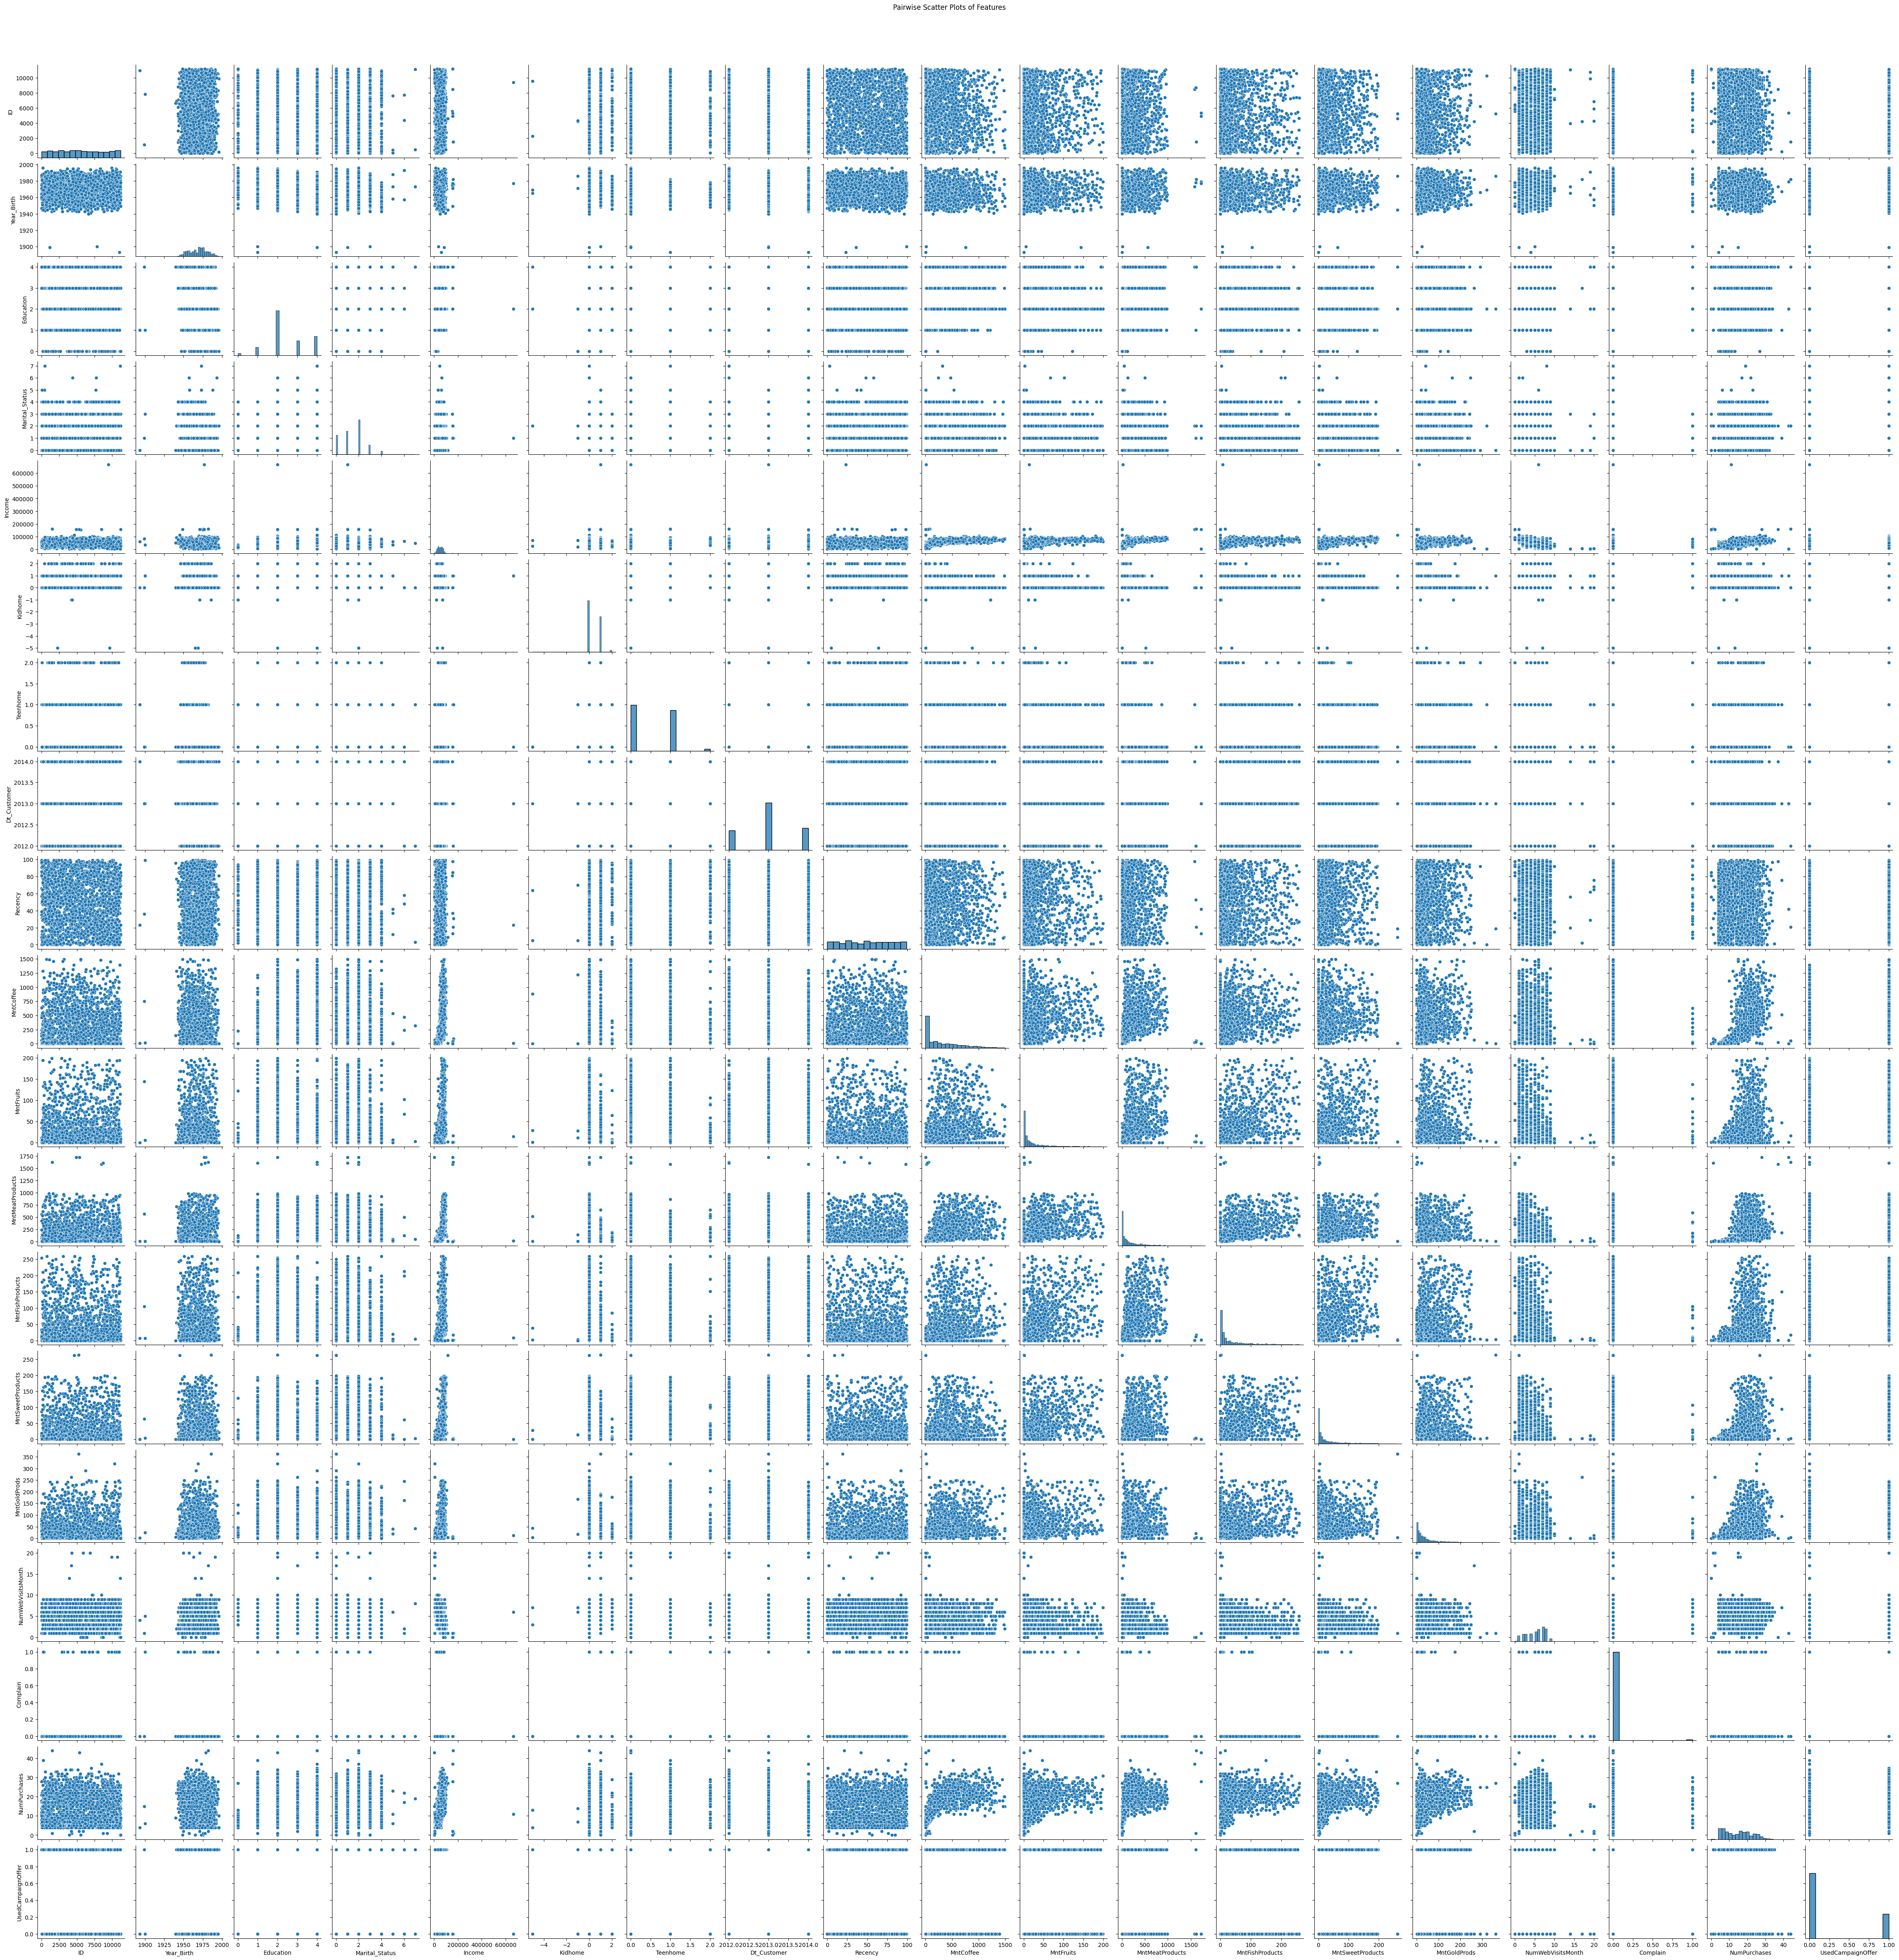

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plots for each pair of features
sns.pairplot(data)
plt.suptitle("Pairwise Scatter Plots of Features", y=1.02)
plt.show()

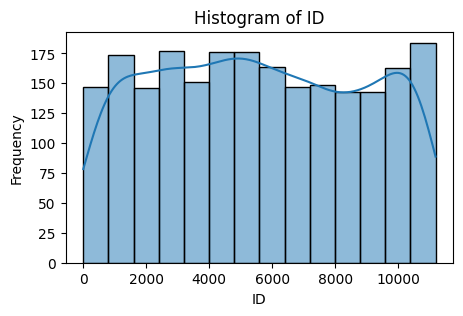

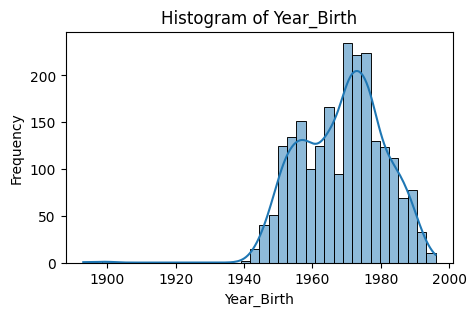

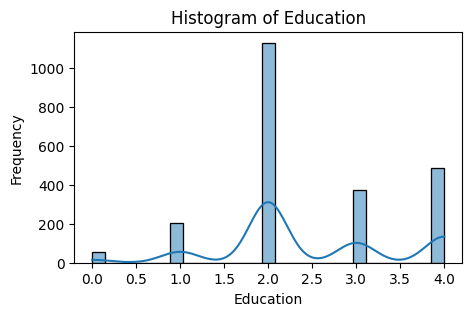

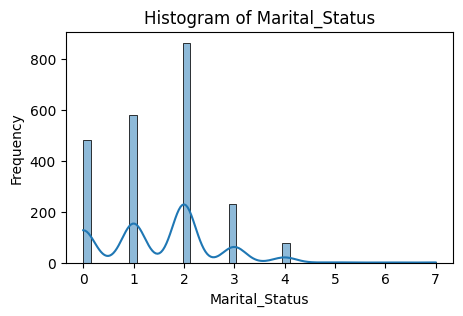

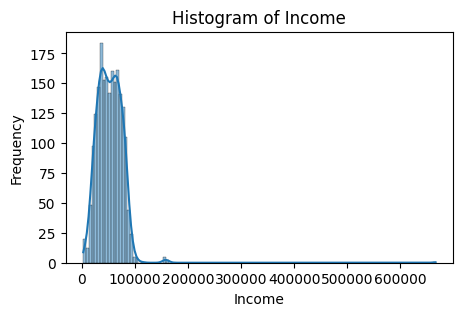

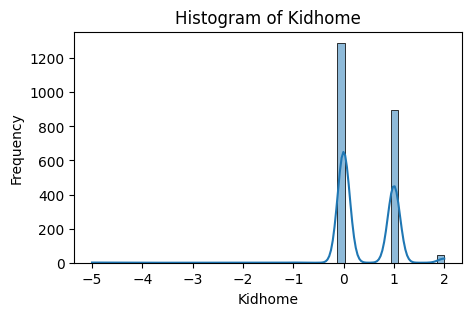

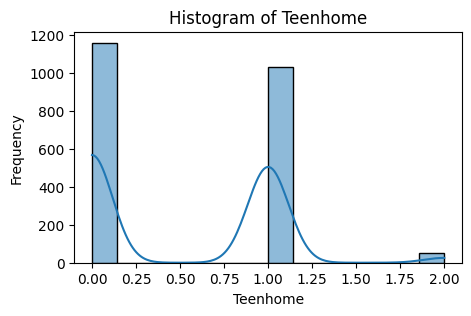

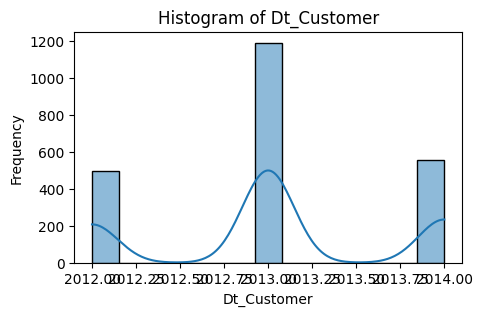

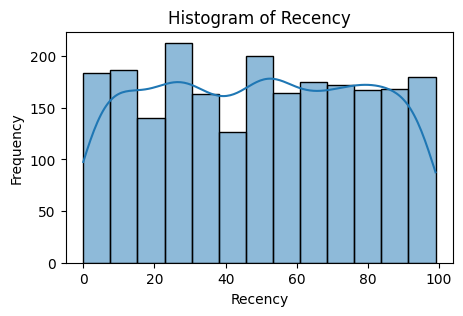

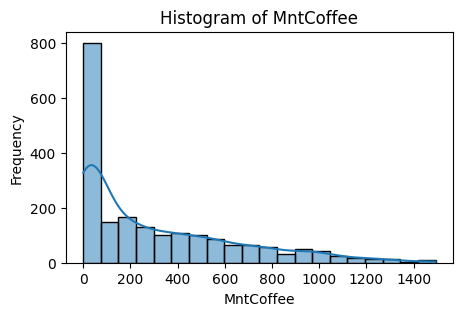

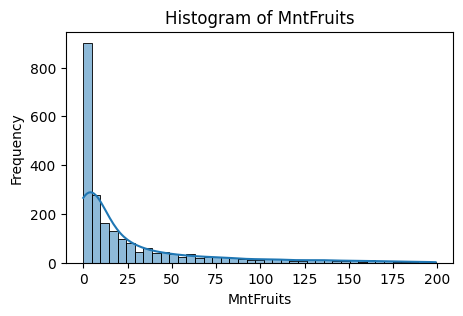

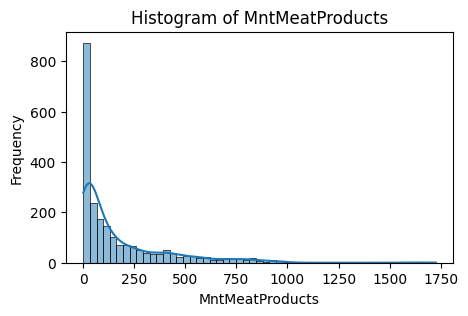

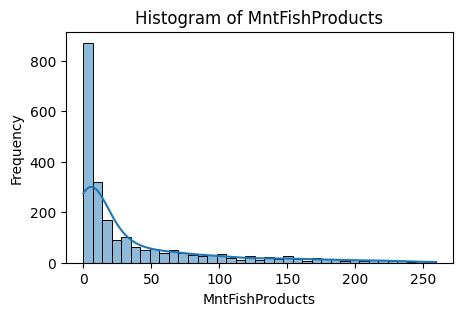

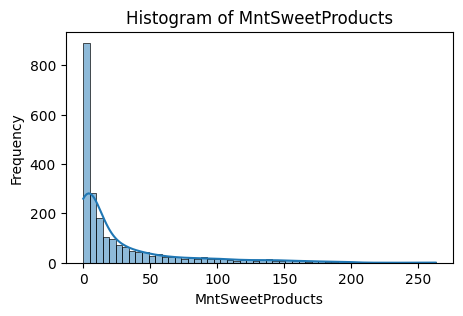

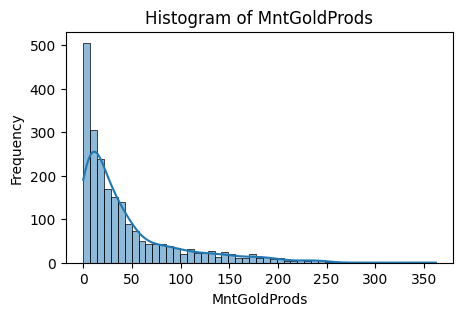

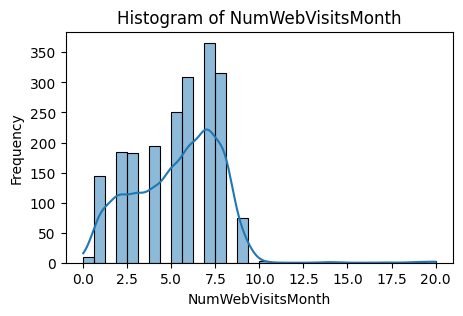

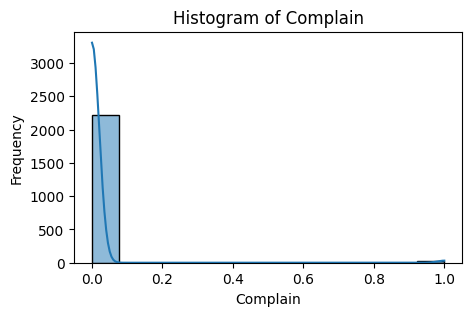

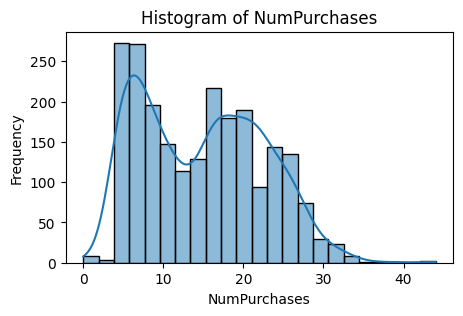

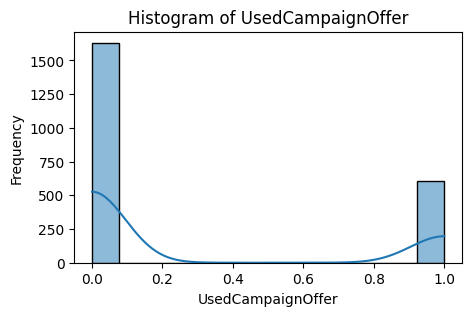

In [7]:
# Histogram for each feature
for column in data.columns:
    plt.figure(figsize=(5, 3))
    sns.histplot(data[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


Pearson correlation coefficient with target column (NumPurchases):
ID                   -0.02383
Year_Birth           -0.16830
Education            0.11737
Marital_Status       0.05713
Income               0.56434
Kidhome              -0.44707
Teenhome             0.13316
Dt_Customer          -0.18113
Recency              0.00574
MntCoffee            0.71596
MntFruits            0.45546
MntMeatProducts      0.55423
MntFishProducts      0.46945
MntSweetProducts     0.47288
MntGoldProds         0.49292
NumWebVisitsMonth    -0.30920
Complain             -0.02058
UsedCampaignOffer    0.25139


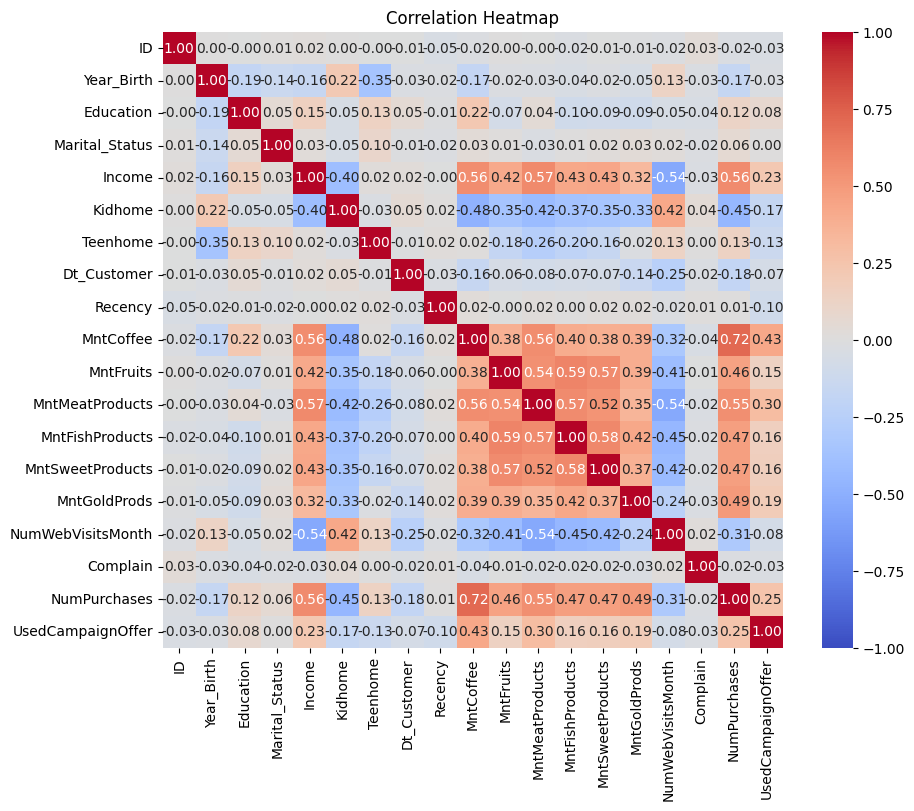

In [16]:
import numpy as np

def pearson_correlation(x, y):
    # Calculate means
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Calculate standard deviations
    std_x = np.std(x)
    std_y = np.std(y)

    # Calculate covariance
    covariance = np.mean((x - mean_x) * (y - mean_y))

    # Calculate correlation coefficient
    correlation = covariance / (std_x * std_y)
    return correlation


# Calculate Pearson correlation coefficient between 'NumPurchases' and other numeric features
correlation_results = {}
target_column = data['NumPurchases']
for column in data.columns:
    if column != 'NumPurchases':
        correlation = pearson_correlation(data[column], target_column)
        correlation_results[column] = correlation

print("Pearson correlation coefficient with target column (NumPurchases):")
for column, correlation in correlation_results.items():
    print(f"{column: <20} {correlation:.5f}")

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# remove ineffective features
# columns with correlation coefficient less than 0.1
columns_to_drop = [column for column, correlation in correlation_results.items() if abs(correlation) < 0.1]

# Drop columns from the DataFrame
data_filtered = data.drop(columns=columns_to_drop)

# Handling missing values
def handle_missing_values(data):
    # Impute missing values with mean for numeric columns
    for column in data.columns:
            mean = data[column].mean()
            data[column].fillna(mean, inplace=True)
    return data

# Normalizing values between 0 and 1 (Min-Max Scaling)
def min_max_scaling(data):
    normalized_data = (data - data.min()) / (data.max() - data.min())
    return normalized_data

# Handle missing values
data_normalized = handle_missing_values(data_filtered)

# Normalize data
data_normalized = min_max_scaling(data_normalized)

# Save normalized DataFrame to new CSV
data_normalized.to_csv('/content/drive/MyDrive/marketing_campaign_normalized.csv', index=False)


In [18]:
# Train-test split
def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split_index = int((1 - test_size) * len(X))
    X_train, X_test = X[indices[:split_index]], X[indices[split_index:]]
    y_train, y_test = y[indices[:split_index]], y[indices[split_index:]]
    return X_train, X_test, y_train, y_test

# Load data
data = pd.read_csv('/content/drive/MyDrive/marketing_campaign_normalized.csv')

# Extract features and target variable
X = data['MntCoffee'].values
y = data['NumPurchases'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
def linear_regression(X_train, y_train):
    # Calculate mean of X and y
    mean_x = np.mean(X_train)
    mean_y = np.mean(y_train)

    # Total number of values
    n = len(X_train)

    # Using formula to find 'a' and 'b'
    numer = 0
    denom = 0
    for i in range(n):
        numer += (X_train[i] - mean_x) * (y_train[i] - mean_y)
        denom += (X_train[i] - mean_x) ** 2
    a = numer / denom
    b = mean_y - (a * mean_x)

    return a, b

def predict(X, a, b):
    return a * X + b

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    mean_y = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_y) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

# Train linear regression model
a, b = linear_regression(X_train, y_train)

# Make predictions on test set
y_pred = predict(X_test, a, b)

# Evaluate model
rmse_value = rmse(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print("a=", a, "\nb=", b)
print("\nRMSE:", rmse_value)
print("R2 Score:", r2_value)


a= 0.545128125976073 
b= 0.227750210067017

RMSE: 0.13348950323313033
R2 Score: 0.44338797372141714


In [25]:
def normalize_features(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_normalized = (X - mean) / std
    return X_normalized, mean, std

def gradient_descent_multi(X, y, alpha=0.01, iterations=1000):
    m = len(y)
    n = X.shape[1]
    theta = np.zeros(n)
    cost_history = []

    for _ in range(iterations):
        error = np.dot(X, theta) - y
        gradient = np.dot(X.T, error) / m
        theta -= alpha * gradient
        cost = np.sum(error ** 2) / (2 * m)
        cost_history.append(cost)

    return theta, cost_history

# Select features and target variable
features = ["Income", "MntCoffee", "MntFruits"]
X = data[features].values
y = data['NumPurchases'].values

# Normalize features
X_normalized, mean, std = normalize_features(X)

# Add intercept term to X
X_normalized = np.column_stack((np.ones(len(X_normalized)), X_normalized))

# Run gradient descent
theta, cost_history = gradient_descent_multi(X_normalized, y)

# Print learned parameters
print("Learned parameters:")
for i, feature in enumerate(["Intercept"] + features):
    print(f"{feature}: {theta[i]:.4f}")

# Predictions
y_pred = np.dot(X_normalized, theta)

# Calculate RMSE and R2 Score
rmse_value = rmse(y, y_pred)
r2_value = r2_score(y, y_pred)
print("\nRMSE:", rmse_value)
print("R2 Score:", r2_value)

Learned parameters:
Intercept: 0.3378
Income: 0.0344
MntCoffee: 0.0891
MntFruits: 0.0335

RMSE: 0.11806515724162404
R2 Score: 0.5419212271370027
